# Load the dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv('./Mall_Customers.csv')  
df.head()



,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
X = df.iloc[:,3:].values
print(X)

[[ 15  39]
 [ 15  81]
 [ 16   6]
 [ 16  77]
 [ 17  40]
 [ 17  76]
 [ 18   6]
 [ 18  94]
 [ 19   3]
 [ 19  72]
 [ 19  14]
 [ 19  99]
 [ 20  15]
 [ 20  77]
 [ 20  13]
 [ 20  79]
 [ 21  35]
 [ 21  66]
 [ 23  29]
 [ 23  98]
 [ 24  35]
 [ 24  73]
 [ 25   5]
 [ 25  73]
 [ 28  14]
 [ 28  82]
 [ 28  32]
 [ 28  61]
 [ 29  31]
 [ 29  87]
 [ 30   4]
 [ 30  73]
 [ 33   4]
 [ 33  92]
 [ 33  14]
 [ 33  81]
 [ 34  17]
 [ 34  73]
 [ 37  26]
 [ 37  75]
 [ 38  35]
 [ 38  92]
 [ 39  36]
 [ 39  61]
 [ 39  28]
 [ 39  65]
 [ 40  55]
 [ 40  47]
 [ 40  42]
 [ 40  42]
 [ 42  52]
 [ 42  60]
 [ 43  54]
 [ 43  60]
 [ 43  45]
 [ 43  41]
 [ 44  50]
 [ 44  46]
 [ 46  51]
 [ 46  46]
 [ 46  56]
 [ 46  55]
 [ 47  52]
 [ 47  59]
 [ 48  51]
 [ 48  59]
 [ 48  50]
 [ 48  48]
 [ 48  59]
 [ 48  47]
 [ 49  55]
 [ 49  42]
 [ 50  49]
 [ 50  56]
 [ 54  47]
 [ 54  54]
 [ 54  53]
 [ 54  48]
 [ 54  52]
 [ 54  42]
 [ 54  51]
 [ 54  55]
 [ 54  41]
 [ 54  44]
 [ 54  57]
 [ 54  46]
 [ 57  58]
 [ 57  55]
 [ 58  60]
 [ 58  46]
 [ 59  55]

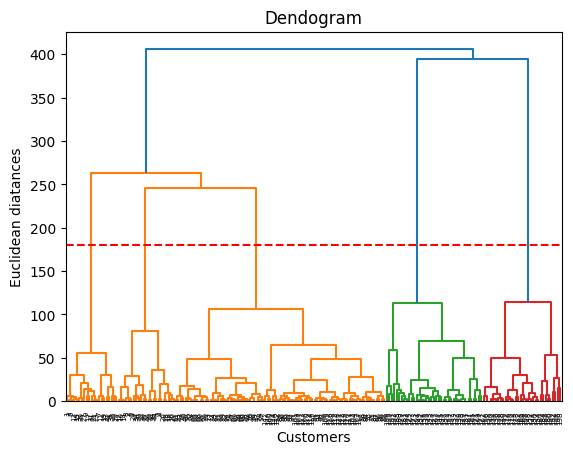

In [10]:
import scipy.cluster.hierarchy as sch

dendogram = sch.dendrogram(sch.linkage(X,method ='ward'))
plt.axhline(y=180, color='r', linestyle='--')
plt.title('Dendogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean diatances')
plt.show()

In [7]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='ward')
y_hc = hc.fit_predict(X)
print(y_hc)

[4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4
 3 4 3 4 3 4 1 4 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 1 2 0 2 0 2 1 2 0 2 0 2 0 2 0 2 1 2 0 2 1 2
 0 2 0 2 0 2 0 2 0 2 0 2 1 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2]


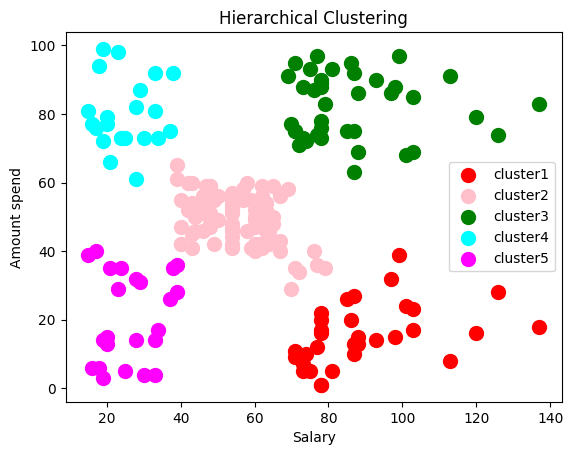

In [8]:
plt.scatter(X[y_hc==0,0],X[y_hc == 0,1] , s=100, c='red' ,label= 'cluster1')
plt.scatter(X[y_hc==1,0],X[y_hc == 1,1] , s=100, c='pink' ,label= 'cluster2')
plt.scatter(X[y_hc==2,0],X[y_hc == 2,1] , s=100, c='green' ,label= 'cluster3')
plt.scatter(X[y_hc==3,0],X[y_hc == 3,1] , s=100, c='cyan' ,label= 'cluster4')
plt.scatter(X[y_hc==4,0],X[y_hc == 4,1] , s=100, c='magenta' ,label= 'cluster5')
plt.xlabel('Salary')
plt.ylabel('Amount spend')
plt.title('Hierarchical Clustering')
plt.legend()
plt.show()

In [9]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X,y_hc)
print("shilhouette score is : ",score)

shilhouette score is :  0.5529945955148897


Silhouette Score measures:

How well a data point fits inside its cluster compared to other clusters.

*It tells us:*

- Are clusters tight and well separated?

- Or are they messy and overlapping?


$Interpretation$

Close to +1 → Well separated clusters

Around 0 → Clusters overlap

Negative → Data point is in wrong cluster

### PCA

In [16]:
feature_names = vectorizer.get_feature_names_out()
 
for cluster in range(n_clusters):
    print(f"\nCluster {cluster}")
   
    cluster_indices = np.where(labels == cluster)
    cluster_tfidf = X_dense[cluster_indices]
   
    mean_tfidf = np.mean(cluster_tfidf, axis=0)
    top_indices = mean_tfidf.argsort()[-10:][::-1]
   
    top_words = [feature_names[i] for i in top_indices]
    print("Top Words:", top_words)
 

NameError: name 'vectorizer' is not defined

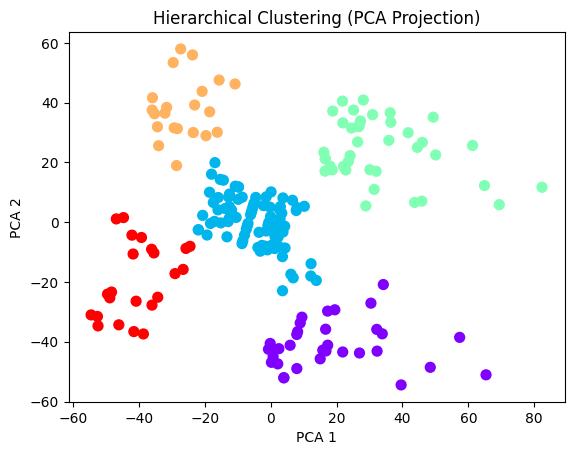

In [18]:
from sklearn.decomposition import PCA
# X_dense = X.todense() if hasattr(X, "todense") else X
# labels = hc.labels_

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_dense)

plt.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    c= labels,
    cmap = 'rainbow',
    s=50
)

plt.title("Hierarchical Clustering (PCA Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

Silhouette Score: 0.5529945955148897
